# Estimate AO system throughput

In [28]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import jv, kv
from scipy.special import j1 # Bessel function of the first kind of order 1, for the diffraction pattern calculation
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi
import scipy.integrate as integrate

In [29]:
# jn_zeros is a function that returns the zeros of the Bessel function of the first kind, 
# which are needed to find the roots for the LP01 mode in a step-index fibre
from scipy.special import jn_zeros  # NEW: needed to get the first zero of J0

In [30]:
from scipy.optimize import brentq
from scipy.optimize import fminbound
from scipy.signal import fftconvolve

In [31]:
R_approx = 0.97
N_mirrors = 7
R_M8 = 0.97 # deformable mirror reflectivity
R_M9 = 0.97 # dichroic mirror reflectivity 
R_M10 = 0.97

In [32]:
R_tot = (R_approx**N_mirrors) * R_M8 * R_M9
R_tot

0.760231058654565

## Approximate Strehl Ratio in H-band

In [33]:
def marechal_strehl(Strehl_ref, wavelength_ref, wavelength_observed): 
    """
    Calculate the Strehl ratio using Marechal's approximation.

    Parameters:
    Strehl_ref (float): The reference Strehl ratio at the reference wavelength.
    wavelength_ref (float): The reference wavelength (in the same units as wavelength_observed, metres).
    wavelength_observed (float): The observed wavelength (in the same units as wavelength_ref, metres). 

    Returns: 
    Strehl_observed (float): The estimated Strehl ratio at the observed wavelength.
    sigma_WFE (float): The wavefront error in radians at the observed wavelength.
    """

    # Calculate the wavefront error in physical units (meters), not a fraction of the wavelength
    sigma_WFE = wavelength_ref * np.sqrt(-np.log(Strehl_ref)) / (2 * np.pi) 

    # Calculate the Strehl ratio of the observed wavelength using Marechal's approximation
    Strehl_observed = np.exp(-(2 * np.pi * sigma_WFE / wavelength_observed)**2)

    return Strehl_observed, sigma_WFE

In [34]:
print("If the Strehl ratio at 2.2 microns is 0.7:")
print(f"Strehl ratio at H-band 1.5 microns = {marechal_strehl(0.7, 2.2e-6, 1.5e-6)[0]:.3f}")
print(f"Wavefront error at S(2.2micron)~0.7 = {marechal_strehl(0.7, 2.2e-6, 1.5e-6)[1]:.3e} metres")

If the Strehl ratio at 2.2 microns is 0.7:
Strehl ratio at H-band 1.5 microns = 0.464
Wavefront error at S(2.2micron)~0.7 = 2.091e-07 metres


In [35]:
print("If the Strehl ratio at 2.2 microns is 0.6:")
print(f"Strehl ratio at H-band 1.5 microns = {marechal_strehl(0.6, 2.2e-6, 1.5e-6)[0]:.3f}")
print(f"Wavefront error at S(2.2micron)~0.6 =  {marechal_strehl(0.6, 2.2e-6, 1.5e-6)[1]:.3e} metres")

If the Strehl ratio at 2.2 microns is 0.6:
Strehl ratio at H-band 1.5 microns = 0.333
Wavefront error at S(2.2micron)~0.6 =  2.503e-07 metres


In [36]:
print("If the Strehl ratio at 2.2 microns is 0.4:")
print(f"Strehl ratio at H-band 1.5 microns = {marechal_strehl(0.4, 2.2e-6, 1.5e-6)[0]:.3f}")
print(f"Wavefront error at S(2.2micron)~0.4 = {marechal_strehl(0.4, 2.2e-6, 1.5e-6)[1]:.3e} metres")

If the Strehl ratio at 2.2 microns is 0.4:
Strehl ratio at H-band 1.5 microns = 0.139
Wavefront error at S(2.2micron)~0.4 = 3.352e-07 metres


In [37]:
print("If the Strehl ratio at 2.2 microns is 0.7:")
print(f"Strehl ratio at J-band 1.25 microns = {marechal_strehl(0.7, 2.2e-6, 1.25e-6)[0]:.3f}")
print(f"Wavefront error at S(2.2micron)~0.7 = {marechal_strehl(0.7, 2.2e-6, 1.25e-6)[1]:.3e} metres")

If the Strehl ratio at 2.2 microns is 0.7:
Strehl ratio at J-band 1.25 microns = 0.331
Wavefront error at S(2.2micron)~0.7 = 2.091e-07 metres


## Convolve the PSF with Jitter

Let's make an Airy function for the F=5/# image at focal plane. 

We then convolve that Airy function of the point source at diffraction limit with the jitter, which is expected to be 20 milliarcsecond root mean square. 

In [38]:
def diffraction_limited_E_field_at_fibre_2d(x, y, lam0, F_eff, alpha=0.0, E_S=1.0, decentre=None):
    """
    Diffraction-limited telescope image electric field evaluated
    on a 2D grid at the fibre input plane.

    Parameters
    ----------
    x, y : 2D arrays
        Cartesian coordinates at the fibre input plane [m].
        The fibre centre is assumed to be at x=0, y=0.
    lam0 : float
        Wavelength [m].
    F_eff : float
        Effective focal ratio at the fibre input plane.
    alpha : float
        Central obstruction ratio.
    E_S : float
        Overall field amplitude.
    decentre : None or tuple
        If None, the image is centred on the fibre.
        If (dx, dy), the image centre is shifted by dx, dy [m]
        relative to the fibre centre.

    Returns
    -------
    E_image : 2D array
        Electric field at the fibre input plane.
    I_image : 2D array
        Intensity at the fibre input plane.
    """

    if decentre is None:
        dx, dy = 0.0, 0.0
        r_image = np.sqrt(x**2 + y**2)

    else:
        dx, dy = decentre
        # Coordinates relative to the centre of the image/PSF
        x_shifted = x - dx
        y_shifted = y - dy # if we set phi=0, the vertical shift would become zero as we 
        # later set dy=rsin(phi)=r, assuming the shift is purely radial

        # The radial distance from the centre of the PSF is calculated using the coordinates
        r_image = np.sqrt(x_shifted**2 + y_shifted**2)

    # Compute s, the normalized radial coordinate in the image plane, which is used to calculate the Airy pattern.
    s = np.pi * r_image / (lam0 * F_eff)

    airy_term = np.divide(2 * j1(s), s, # Airy pattern term 2*J1(s)/s, which describes the diffraction pattern of a circular aperture.
        out=np.ones_like(s),
        where=s != 0   # to avoid division by zero at the centre of the PSF, where s=0. The limit of 2*j1(s)/s as s->0 is 1, which is consistent with the Airy pattern having a maximum value of 1 at the centre.
    )

    if alpha > 0:
        obstruction_term = np.divide(2 * j1(alpha * s), alpha * s,
            out=np.ones_like(s),
            where=(alpha * s) != 0   # to avoid division by zero at the centre of the PSF, where alpha * s = 0
        )
        E_image = E_S * (airy_term - alpha**2 * obstruction_term)
    else:
        E_image = E_S * airy_term

    I_image = np.abs(E_image)**2

    return E_image, I_image

### Estimating the seeing-limited halo at ($1.5\,\mu\mathrm{m}$)

The seeing FWHM is scaled from the VLT White Book value of 0.4 arcsec at $500\,\mathrm{nm}$ using the Kolmogorov wavelength dependence

$$
\mathrm{FWHM}(\lambda)
=
\mathrm{FWHM}_0
\left(
\frac{\lambda}{\lambda_0}
\right)^{-1/5}.
$$

This is used to estimate the seeing at \(1.5\,\mu\mathrm{m}\). The corresponding Fried parameter is then calculated from

$$
r_0
\approx
0.98\frac{\lambda}{\mathrm{FWHM}},
$$

where the FWHM is converted from arcseconds to radians.

The estimated FWHM at \(1.5\,\mu\mathrm{m}\) is then used as the width of a Moffat profile to approximate the long-exposure seeing-limited halo. The Moffat profile will subsequently be used to construct an approximate halo electric-field distribution for the partial-AO fibre-coupling model.

In [39]:
# def seeing_limited_E_field_at_fibre_2d(): 
    

In [40]:
core_radius_range_test = np.arange(2.5e-6, 30e-6 + 0.5e-6, 0.05e-6) # from 2 to 50 microns in meters, note arange is exclusive of the endpoint, so we add 0.5e-6 to include 30e-6 in the range
lam0 = 1.5e-6
NA = 0.1
F_fibre = 1 / (2 * np.tan(np.arcsin(NA)))
alpha = 0.0
E_S = 1.0

In [41]:
r_max = 125e-6
n_grid = 1000

x_1d = np.linspace(-r_max, r_max, n_grid)
y_1d = np.linspace(-r_max, r_max, n_grid)

x, y = np.meshgrid(x_1d, y_1d)

In [42]:
# Seeing wavelength scaling:
# FWHM(lambda) = FWHM_ref * (lambda / lambda_ref)**(-1/5)

FWHM_ref_arcsec = 0.4       # seeing at the reference wavelength [arcsec]
lambda_ref = 0.5e-6         # reference wavelength [m]
lambda_obs = 1.5e-6         # observing wavelength [m]

# Scale the seeing FWHM from 0.5 microns to 1.5 microns
FWHM_1p5micron_arcsec = FWHM_ref_arcsec * (lambda_obs / lambda_ref)**(-1/5)

# Convert seeing FWHM from arcsec to radians
FWHM_1p5micron_rad = FWHM_1p5micron_arcsec / 206265.0

# Estimate the Fried parameter using:
# FWHM ≈ 0.98 * lambda / r0
# r0 = 0.98 * lambda / FWHM

r0_1p5micron = 0.98 * (lambda_obs / FWHM_1p5micron_rad)

print(f"Seeing FWHM at 1.5 microns: {FWHM_1p5micron_arcsec:.5f} arcsec")
print(f"Fried parameter at 1.5 microns: {r0_1p5micron:.5f} m") 

Seeing FWHM at 1.5 microns: 0.32110 arcsec
Fried parameter at 1.5 microns: 0.94429 m


In [43]:
def moffat_halo_intensity_at_fibre_2d(
        x,
        y,
        seeing_FWHM_arcsec,
        F_eff,
        D_tel,
        beta=4.765, # turbulence induced seeing
        amplitude=1.0,
        decentre=None,
):
    """
    Seeing-limited Moffat profile evaluated on a 2D grid
    at the fibre input plane.

    Parameters
    ----------
    x, y : 2D arrays
        Cartesian coordinates at the fibre input plane [m].
    seeing_fwhm_arcsec : float
        Seeing FWHM at the observing wavelength [arcsec].
    F_eff : float
        Effective focal ratio at the fibre input plane.
    D_tel : float
        Telescope diameter [m].
    beta : float
        Moffat wing parameter.
    E_S : float
        Overall field-amplitude scaling.
    decentre : None or tuple
        Shift of the Moffat-profile centre [m].

    Returns
    -------
    E_halo : 2D array
        Approximate halo electric-field amplitude.
    I_halo : 2D array
        Moffat intensity profile.
    """

    if beta <= 1: 
        raise ValueError("Moffat beta parameter must be greater than 1 for a physical profile with finite total flux.")
    
    if decentre is None: 
        dx, dy = 0.0, 0.0
    else: 
        dx, dy = decentre
    
    x_shifted = x - dx 
    y_shifted = y - dy 
    # The radial distance from the centre of the Moffat profile is calculated using the shifted coordinates
    r_image = np.sqrt(x_shifted**2 + y_shifted**2)

    # Convert the angular seeing FWHM into a physical width at the input focal plane 
    seeing_rad = seeing_FWHM_arcsec / 206265.0
    # effective focal length used after re-imaging
    f_eff = F_eff * D_tel 
    # Calculate the physical size of the seeing disk at the focal plane using the effective focal length and the angular size of the seeing
    FWHM_physical = f_eff * seeing_rad

    # Convert Moffat FWHM to its radial scale parameter. 
    alpha_moffat = FWHM_physical / (2.0 * np.sqrt(2**(1/beta) - 1))

    # Calculate the Moffat intensity profile
    I_halo = (1 + (r_image / alpha_moffat)**2)**(-beta)

    # Normalize the Moffat profile so that its peak intensity is equal to the specified amplitude
    I_halo_norm = amplitude * I_halo / np.max(I_halo)

    # The electric field amplitude is the square root of the intensity
    E_halo_norm = np.sqrt(I_halo_norm) # Note this approximate assigns flat phase to the entire halo

    return E_halo_norm, I_halo_norm

In [44]:
def normalize_intensity_2d(I, x, y):
    dx = x[0, 1] - x[0, 0]
    dy = y[1, 0] - y[0, 0]

    total_power = np.sum(I) * dx * dy

    if total_power <= 0:
        raise ValueError("Intensity must have positive total power.")

    return I / total_power

In [45]:
def gaussian_jitter_kernel_2d(x, y, jitter_rms_mas, F_eff, D_tel): 
    """
    Normalized 2D Gaussian kernel representing the residual tip-tilt jitter of the PSF at the fibre input plane.

    Parameters 
    ----------
    x, y : 2D arrays
        Cartesian coordinates at the fibre input plane [m]. 
    jitter_rms_mas : float
        One axis Gaussian RMS tip-tilt jitter in milliarcseconds.
    F_eff : float
        Effective focal ratio at the fibre front.
    D_tel : float
        Diameter of the telescope primary mirror [m]. 

    Returns: 
    -------
    kernel : 2D array
        Normalized Gaussian kernel representing the tip-tilt jitter in the focal plane.
    sigma_jitter : float
        The standard deviation of the Gaussian jitter in meters at the focal plane.
    """

    # Conert jitter from milliarcseconds to radians
    jitter_rms_arcsec = jitter_rms_mas / 1000.0
    jitter_rms_rad = jitter_rms_arcsec / 206265.0

    f_eff = F_eff * D_tel
    # Convert the angular jitter to a physical jitter at the focal plane
    sigma_jitter = f_eff * jitter_rms_rad

    # r2 is the squared radial distance from the centre of the PSF in the focal plane, calculated using the x and y coordinates
    r2 = x**2 + y**2 

    # Two-dimensional Gaussian jitter distribution
    kernel = np.exp(-r2 / (2.0 * sigma_jitter**2))

    # Normalize the kernel to unit integrated area
    kernel = normalize_intensity_2d(
        kernel,
        x,
        y,
    )

    return kernel, sigma_jitter
    

In [46]:
# COnvolve the airy intensity with the jitter Gaussian kernel

# Generate the diffraction-limited Airy field and intensity
E_airy, I_airy = diffraction_limited_E_field_at_fibre_2d(
    x=x,
    y=y,
    lam0=lam0,
    F_eff=F_fibre,
    alpha=alpha,
    E_S=E_S,
)

# Normalize the Airy intensity to unit integrated power
I_airy_norm = normalize_intensity_2d(
    I_airy,
    x,
    y,
)

# Generate the normalized Gaussian jitter kernel
jitter_kernel, sigma_jitter = gaussian_jitter_kernel_2d(
    x=x,
    y=y,
    jitter_rms_mas=20.0,
    F_eff=F_fibre,
    D_tel=8.0,
)

# Pixel dimensions at the fibre input plane
dx = x[0, 1] - x[0, 0]
dy = y[1, 0] - y[0, 0]

# Convolve the Airy intensity with the jitter distribution
I_core_jittered = fftconvolve(
    I_airy_norm,
    jitter_kernel,
    mode="same",
) * dx * dy

# Normalize after convolution to account for numerical edge effects
I_core_jittered_norm = normalize_intensity_2d(
    I_core_jittered,
    x,
    y,
)

print(
    f"Jitter RMS at the fibre plane: "
    f"{sigma_jitter * 1e6:.3f} microns"
)

print(
    f"Integrated jittered-core power: "
    f"{np.sum(I_core_jittered_norm) * dx * dy:.6f}"
)

Jitter RMS at the fibre plane: 3.859 microns
Integrated jittered-core power: 1.000000


In [47]:
# fftconvolve?

In [48]:
I_airy_norm = normalize_intensity_2d(I_airy, x, y)

jitter_kernel, sigma_jitter = gaussian_jitter_kernel_2d(
    x=x, y=y, 
    jitter_rms_mas = 20.0, 
    F_eff=F_fibre, 
    D_tel=8.0
)

dx = x[0, 1] - x[0, 0]
dy = y[1, 0] - y[0, 0]

# Convolve the diffraction limited Airy pattern with the Gaussian jitter kernel to get the 
# jitter-convolved PSF core intensity at the fibre input plane. The convolution is done using 
# fftconvolve for efficiency, and we multiply by dx*dy to account for the pixel area in the 
# convolution.
I_core_jittered = fftconvolve(I_airy_norm, jitter_kernel, mode='same') * dx * dy

I_core_jittered_norm = normalize_intensity_2d(I_core_jittered, x, y)


In [49]:
# Step 4: Generate the seeing-limited Moffat halo

# Generate the peak-normalized Moffat seeing halo
E_halo_approx, I_halo_peak_norm = (
    moffat_halo_intensity_at_fibre_2d(
        x=x,
        y=y,
        seeing_FWHM_arcsec=FWHM_1p5micron_arcsec,
        F_eff=F_fibre,
        D_tel=8.0,
        beta=4.765,
        amplitude=1.0,
        decentre=None,
    )
)

# Convert the halo to unit integrated power
I_halo_power_norm = normalize_intensity_2d(
    I_halo_peak_norm,
    x,
    y,
)

print(
    f"Integrated halo power: "
    f"{np.sum(I_halo_power_norm) * dx * dy:.6f}"
)

Integrated halo power: 1.000000


In [50]:
# # Normalize the jitter-convolved Airy core to unit integrated power

# core_total_power = np.sum(I_core_jittered) * dx * dy

# if core_total_power <= 0:
#     raise ValueError("The jitter-convolved Airy core has zero or negative total power.")

# I_core_jittered_power_norm = I_core_jittered / core_total_power

In [66]:
def partial_AO_PSF_intensity_2d(I_core_jittered, I_halo, x, y, strehl): 
    """
    Combine a jitter-broadened diffraction-limited core and
    a seeing-limited Moffat halo.

    Parameters
    ----------
    strehl : float
        Fraction of the normalized PSF power assigned to the
        corrected core in this simplified model.
    I_core_jittered : 2D array
        Intensity of the jitter-broadened diffraction-limited core, normalized to unit integrated power.
    I_halo : 2D array
        Intensity of the seeing-limited Moffat halo, normalized to unit integrated power.
    """
    if not 0.0 <= strehl <= 1.0: 
        raise ValueError("Strehl ratio must be between 0 and 1.")

    # The jittered core is the AO-corrected part of the PSF
    I_core_jittered_norm = normalize_intensity_2d(I_core_jittered, x, y)
    
    # The halo is the uncorrected part of the PSF
    I_halo_norm = normalize_intensity_2d(I_halo, x, y)

    # I_psf_tot= S*I_psf_corrected + (1 - S) * I_halo
    I_AO_final = strehl * I_core_jittered_norm + (1 - strehl) * I_halo_norm

    I_AO_final_norm = normalize_intensity_2d(I_AO_final, x, y)

    return I_AO_final_norm


In [52]:
# # Step 5: Construct the simplified partial-AO PSF

# if not 0.0 <= strehl_H <= 1.0: 
#     raise ValueError("Strehl ratio must be between 0 and 1.")

In [68]:
strehl_H = 0.464

# The intensity is the added combination I_psf_tot= S*I_psf_corrected + (1 - S) * I_halo, 
# where the corrected core is represented by the jitter-convolved Airy pattern, and the 
# uncorrected halo is represented by the Moffat profile. Both components are normalized to 
# unit integrated power before combining, and the final combined PSF is also normalized 
# to unit integrated power to ensure it represents a valid intensity distribution. 

I_AO_final = partial_AO_PSF_intensity_2d(
    I_core_jittered=I_core_jittered_norm,
    I_halo=I_halo_power_norm,
    x=x,
    y=y,
    strehl=strehl_H,
)

print(
    f"Integrated partial-AO PSF power: "
    f"{np.sum(I_AO_final) * dx * dy:.6f}"
)

Integrated partial-AO PSF power: 1.000000


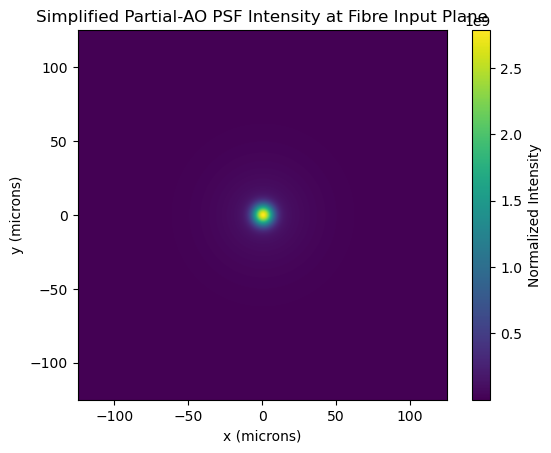

In [69]:
plt.imshow(I_AO_final, extent=(x.min()*1e6, x.max()*1e6, y.min()*1e6, y.max()*1e6), origin='lower')
plt.xlabel('x (microns)')
plt.ylabel('y (microns)')
plt.title('Simplified Partial-AO PSF Intensity at Fibre Input Plane')
plt.colorbar(label='Normalized Intensity')

In [70]:
# Find the grid indices nearest to x = 0 and y = 0
centre_x_index = np.argmin(np.abs(x[0, :]))
centre_y_index = np.argmin(np.abs(y[:, 0]))

# Physical x-coordinate through the centre of the PSF
x_1d = x[centre_y_index, :]

# Take a horizontal slice through y = 0
I_AO_1d = I_AO_final[centre_y_index, :]

# Approximate electric-field amplitude
E_AO_amplitude_1d = np.sqrt(
    np.clip(I_AO_1d, 0.0, None)
)

# Normalize only for visual comparison
I_AO_1d_plot = I_AO_1d / np.max(I_AO_1d)
E_AO_1d_plot = E_AO_amplitude_1d / np.max(E_AO_amplitude_1d)

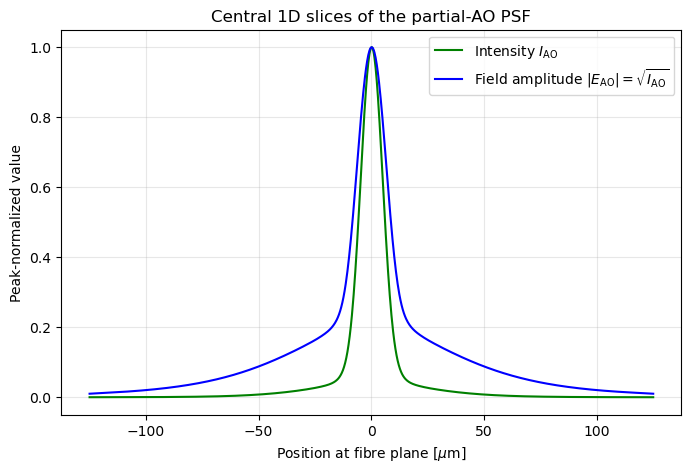

In [71]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_1d * 1e6,
    I_AO_1d_plot, color='green', 
    label=r"Intensity $I_{\rm AO}$",
)

plt.plot(
    x_1d * 1e6,
    E_AO_1d_plot, color='blue',
    label=r"Field amplitude $|E_{\rm AO}| = \sqrt{I_{\rm AO}}$",
)

plt.xlabel(r"Position at fibre plane [$\mu$m]")
plt.ylabel("Peak-normalized value")
plt.title("Central 1D slices of the partial-AO PSF")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

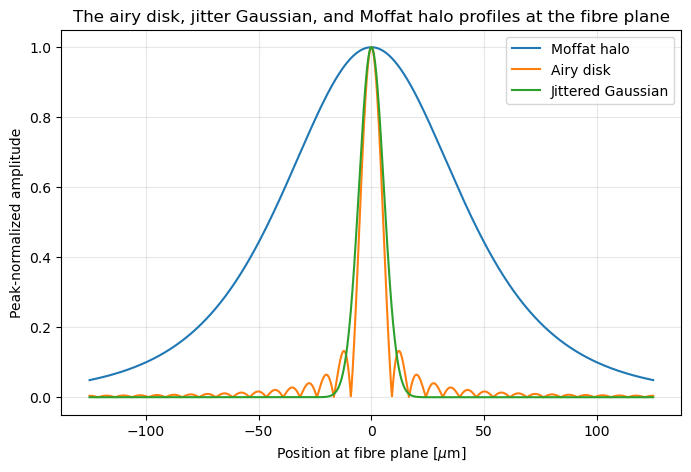

In [75]:
I_airy_disk_1d = I_airy_norm[centre_y_index, :]
E_airy_disk_1d = np.sqrt(np.clip(I_airy_disk_1d, 0.0, None))
E_airy_disk_plot = E_airy_disk_1d / np.max(E_airy_disk_1d)

I_halo_1d = I_halo_power_norm[centre_y_index, :]
E_halo_1d = np.sqrt(np.clip(I_halo_1d, 0.0, None))
E_halo_plot = E_halo_1d / np.max(E_halo_1d)

I_jitter_gaussian_1d = jitter_kernel[centre_y_index, :]
E_jitter_gaussian_1d = np.sqrt(np.clip(I_jitter_gaussian_1d, 0.0, None))
E_jitter_gaussian_plot = E_jitter_gaussian_1d / np.max(E_jitter_gaussian_1d)

plt.figure(figsize=(8, 5))

plt.plot(
    x_1d * 1e6,
    E_halo_plot,
    label="Moffat halo",
)
plt.plot(
    x_1d * 1e6,
    E_airy_disk_plot,
    label="Airy disk",
)
plt.plot(
    x_1d * 1e6,
    E_jitter_gaussian_plot,
    label="Jittered Gaussian",
)

plt.xlabel(r"Position at fibre plane [$\mu$m]")
plt.ylabel("Peak-normalized amplitude")
plt.title("The airy disk, jitter Gaussian, and Moffat halo profiles at the fibre plane")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_45352/896520108.py:19: SyntaxWarning: invalid escape sequence '\s'
  label="Airy Core $\star$ Gaussian Jitter",


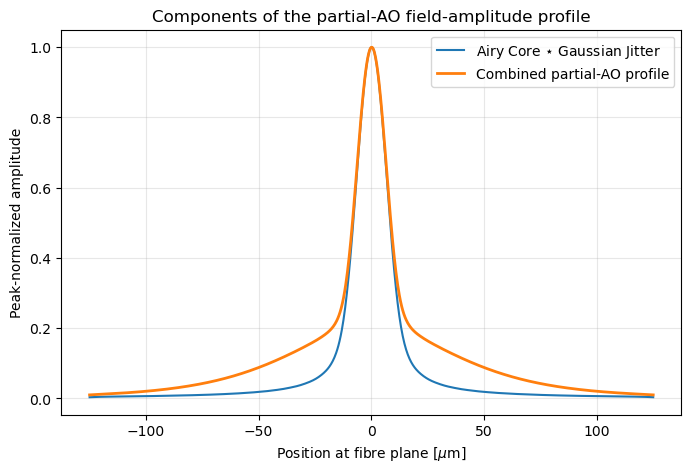

In [76]:
# Central slices
I_core_1d = I_core_jittered_norm[centre_y_index, :]
I_AO_1d = I_AO_final[centre_y_index, :]

# Convert to approximate amplitudes
E_core_1d = np.sqrt(np.clip(I_core_1d, 0.0, None))
E_AO_1d = np.sqrt(np.clip(I_AO_1d, 0.0, None))

# Normalize each profile by its own maximum for comparing shapes
E_core_plot = E_core_1d / np.max(E_core_1d)

E_AO_plot = E_AO_1d / np.max(E_AO_1d)

plt.figure(figsize=(8, 5))

plt.plot(
    x_1d * 1e6,
    E_core_plot,
    label="Airy Core $\star$ Gaussian Jitter",
)


plt.plot(
    x_1d * 1e6,
    E_AO_plot,
    label="Combined partial-AO profile",
    linewidth=2,
)

plt.xlabel(r"Position at fibre plane [$\mu$m]")
plt.ylabel("Peak-normalized amplitude")
plt.title("Components of the partial-AO field-amplitude profile")
plt.grid(alpha=0.3)
plt.legend()
plt.show()